# Pha S — Buoc 2: Tien xu ly & dong bo hoa

**Day la notebook de sai nhat Pha S.** Roadmap goc ghi ro: *"Neu sanity check khong dat, kiem tra pipeline dong bo hoa TRUOC khi nghi ngo mo hinh."*

Chuoi cong viec:
1. ECG -> chuoi RR (dung annotation nhip co san cua slpdb)
2. Loc nhip ngoai tam thu (ectopic)
3. Noi suy RR ve luoi deu 4 Hz
4. EEG -> cong suat dai tan (log) tren **cung luoi** 4 Hz
5. ✅ **Kiem tra dong bo hoa** (test dich thoi gian)
6. Cat cua so 30 giay (N=120) -> `Window`

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import yaml, numpy as np, pandas as pd, matplotlib.pyplot as plt, wfdb
from pathlib import Path

from pqrst.data.real.cardiac import rr_from_beat_annotations, interpolate_rr
from pqrst.data.real.eeg import (
    compute_band_power, detect_cardiac_artifact, remove_cardiac_artifact, EEG_BANDS,
)
from pqrst.data.real.sync import align_to_common_grid, sync_and_window, verify_synchronization
from pqrst.data.real.download import list_local_records
from pqrst.data.synthetic.corpus import save_corpus
from pqrst.baselines.ksg import KSGTEEstimator

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'real'/'preprocessing.yaml', encoding='utf-8'))
# Dung KSG (khong phu thuoc checkpoint) cho verify_synchronization.
est_ksg = KSGTEEstimator()
cfg

{'grid_fs': 4.0,
 'window_seconds': 30.0,
 'step_seconds': 30.0,
 'cardiac': {'keep_beat_symbols': ['N'],
  'rr_physiological_range': [0.3, 2.0],
  'ectopic_threshold_ratio': 0.2,
  'max_removed_fraction': 0.2,
  'interpolation': 'linear'},
 'eeg': {'band': 'alpha',
  'log_transform': True,
  'spectrogram_window_seconds': 4.0},
 'respiration': {'bandpass_hz': [0.1, 0.5]},
 'cardiac_artifact_check': {'window_ms': 200.0,
  'artifact_ratio_threshold': 2.0},
 'sync_check': {'shift_seconds': 10.0, 'max_ratio_for_pass': 0.7},
 'n_bootstrap': 500,
 'n_permutations': 500,
 'seed': 42}

## 1. Kenh tim: ECG -> RR -> luoi deu

In [2]:
record_id = 'slp01a'
ann = wfdb.rdann(str(BASE / 'data' / 'raw' / 'slpdb' / record_id), 'ecg')
beat_times_raw = ann.sample / 250.0
# CHI giu nhip loai 'N' (normal) truoc khi tinh RR - xem docs/PHASE_S_GUIDE.md muc 2.1.
is_normal = np.array([s == 'N' for s in ann.symbol])
beat_times = beat_times_raw[is_normal]
print(f'Tong nhip: {len(beat_times_raw)}, nhip N: {len(beat_times)} '
      f'({len(beat_times)/len(beat_times_raw)*100:.1f}%)')

t_rr, rr = rr_from_beat_annotations(beat_times, exclude_ectopic=True,
                                     threshold_ratio=cfg['cardiac']['ectopic_threshold_ratio'])
removed_frac = 1 - len(rr) / max(len(beat_times) - 1, 1)
print(f'RR con lai sau loc ectopic: {len(rr)}, ty le loai them: {removed_frac*100:.1f}%')
if removed_frac > cfg['cardiac']['max_removed_fraction']:
    print('CANH BAO: loai qua nhieu - ban ghi nay co the qua nhieu artifact.')

t_grid_rr, rr_grid = interpolate_rr(t_rr, rr, grid_fs=cfg['grid_fs'])
print(f'RR grid: {len(rr_grid)} mau, {t_grid_rr[0]:.1f}s -> {t_grid_rr[-1]:.1f}s')

Tong nhip: 7806, nhip N: 7806 (100.0%)
RR con lai sau loc ectopic: 7804, ty le loai them: 0.0%
RR grid: 28796 mau, 0.9s -> 7199.7s


## 2. Ve chuoi RR truoc/sau khi loc ectopic

Nhin bang mat: cac gai nhon bat thuong phai bien mat sau khi loc.

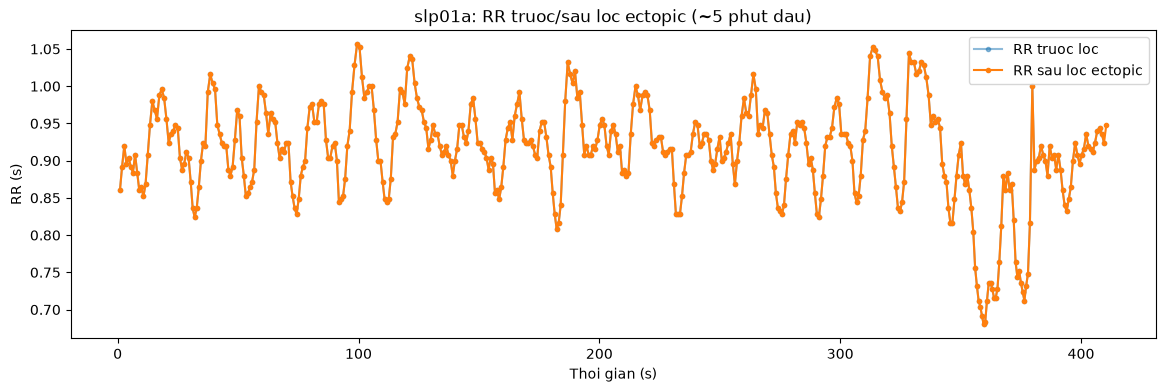

In [3]:
plt.figure(figsize=(14,4))
n_show = 6*75
plt.plot(beat_times_raw[1:n_show], np.diff(beat_times_raw)[:n_show-1], '.-', alpha=0.5, label='RR truoc loc')
plt.plot(t_rr[:n_show], rr[:n_show], '.-', label='RR sau loc ectopic')
plt.xlabel('Thoi gian (s)'); plt.ylabel('RR (s)'); plt.legend()
plt.title(record_id + ': RR truoc/sau loc ectopic (~5 phut dau)')
plt.show()

## 3. Kenh nao: doc tin hieu EEG

In [4]:
record = wfdb.rdrecord(str(BASE / 'data' / 'raw' / 'slpdb' / record_id))
print('Cac kenh:', record.sig_name)
# Ten kenh EEG khac nhau theo ban ghi (montage khac nhau: 'EEG (C4-A1)',
# 'EEG (C3-O1)', 'EEG (O2-A1)',... da xac minh tren nhieu ban ghi slpdb) -
# tim theo TIEN TO 'EEG', khong duoc so khop chinh xac.
eeg_channel = next(s for s in record.sig_name if s.startswith('EEG'))
eeg_idx = record.sig_name.index(eeg_channel)
print('Dung kenh EEG:', eeg_channel)
eeg_sig = record.p_signal[:, eeg_idx]

Cac kenh: ['ECG', 'BP', 'EEG (C4-A1)', 'Resp (sum)']
Dung kenh EEG: EEG (C4-A1)


## 3b. ✅ Kiem tra & khu nhieu truong tim (BAT BUOC)

**Phat hien tren du lieu that (xem docs/PHASE_S_REVIEW.md):** ca 18/18 ban ghi slpdb bi nhiem nhieu tim nang (artifact_ratio 7.9-60.4, nguong 2.0). Da xac minh day la nhiem DIEN THAT (khong phai heartbeat-evoked potential): xung EEG khoa-theo-R-peak dinh dong thoi VA cung do rong (~12-16ms) voi chinh QRS complex cua ECG - HEP thuc su dinh muon hon nhieu (~200-300ms) va rong hon nhieu.

Vi khong co ban ghi 'sach' nao de doi chung, buoc nay se **khu nhieu bang tru template** (`remove_cardiac_artifact`) truoc khi tinh cong suat dai tan. Template chi rong 100ms (dua tren do rong THAT do duoc, ~12-16ms, cong them bien an toan) - KHONG dung toi cac dao dong EEG cham hon (giay) noi ghep noi tim-nao thuc su co the nam. Da validate bang mo phong trong `tests/test_real_data.py::test_remove_cardiac_artifact_removes_artifact_preserves_coupling`: khu duoc nhiem MA van giu >=80% tuong quan ghep noi that.

Neu SAU KHI khu nhieu ma van con vuot nguong -> ban ghi nay bi loai thuc su (nhiem qua nang, khu template khong xu ly duoc).

Truoc khu nhieu: artifact_ratio=36.49 (VUOT NGUONG 2.0 - NGHI NHIEM TIM)
Sau khu nhieu:   artifact_ratio=21.50 (VUOT NGUONG 2.0 - NGHI NHIEM TIM)


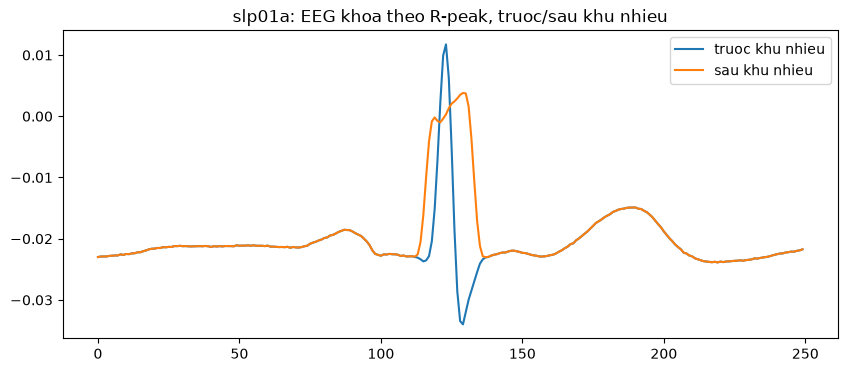

CANH BAO: van con nhiem nhieu SAU khi khu - ban ghi nay nen bi loai.


In [5]:
art_before = detect_cardiac_artifact(
    eeg_sig, beat_times, fs=record.fs,
    artifact_ratio_threshold=cfg['cardiac_artifact_check']['artifact_ratio_threshold'])
print('Truoc khu nhieu:', art_before['message'])

art = art_before
if art_before['suspected']:
    eeg_sig = remove_cardiac_artifact(eeg_sig, beat_times, fs=record.fs)
    art_after = detect_cardiac_artifact(
        eeg_sig, beat_times, fs=record.fs,
        artifact_ratio_threshold=cfg['cardiac_artifact_check']['artifact_ratio_threshold'])
    print('Sau khu nhieu:  ', art_after['message'])
    plt.figure(figsize=(10, 4))
    plt.plot(art_before['locked_average'], label='truoc khu nhieu')
    plt.plot(art_after['locked_average'], label='sau khu nhieu')
    plt.legend(); plt.title(record_id + ': EEG khoa theo R-peak, truoc/sau khu nhieu')
    plt.show()
    if art_after['suspected']:
        print('CANH BAO: van con nhiem nhieu SAU khi khu - ban ghi nay nen bi loai.')
    art = art_after

## 3c. Tinh cong suat dai tan (log), cung luoi 4 Hz

Tinh tren EEG **da khu nhieu** (neu muc 3b phat hien nhiem) - neu tinh truoc khi khu nhieu, cong suat dai tan se bi le thuoc vao xung QRS gia, khong con phan anh dung hoat dong nao.

In [6]:
band = EEG_BANDS[cfg['eeg']['band']]
t_bp, bp = compute_band_power(eeg_sig, fs=record.fs, band=band,
                               window_seconds=cfg['eeg']['spectrogram_window_seconds'],
                               step_seconds=1.0/cfg['grid_fs'])
print(f'Band power ({cfg["eeg"]["band"]}): {len(bp)} mau, {t_bp[0]:.1f}s -> {t_bp[-1]:.1f}s')

Band power (alpha): 29017 mau, 2.0s -> 7198.0s


## 4. Dong bo hoa theo thoi gian THAT (align_to_common_grid)

Khong cat theo do dai mang - 2 chuoi RR-grid va band-power xuat phat tu 2 ham khac nhau, moc t=0 khong trung nhau (xem canh bao trong sync.py).

In [7]:
rr_aligned, bp_aligned = align_to_common_grid(t_grid_rr, rr_grid, t_bp, bp, grid_fs=cfg['grid_fs'])
print(f'Sau dong bo: {len(rr_aligned)} mau chung ({len(rr_aligned)/cfg["grid_fs"]/60:.1f} phut)')

Sau dong bo: 28784 mau chung (119.9 phut)


## 5. ✅ KIEM TRA DONG BO HOA (BAT BUOC)

Dich nhan tao 1 kenh di 10 giay -> TE phai **giam ro** (ratio < `max_ratio_for_pass`). Neu TE **khong doi**, pipeline dang khong do quan he thoi gian -> moi ket luan ve huong ghep noi deu vo nghia. **Dung lai va dieu tra.**

Dung KSG cho test nay (khong phu thuoc checkpoint -> loai bot 1 bien so).

In [8]:
sync_check = verify_synchronization(rr_aligned, bp_aligned, grid_fs=cfg['grid_fs'],
                                     estimator=est_ksg,
                                     shift_seconds=cfg['sync_check']['shift_seconds'],
                                     max_ratio_for_pass=cfg['sync_check']['max_ratio_for_pass'])
print(sync_check)
if sync_check.get('inconclusive'):
    print('KHONG THE KET LUAN - te_aligned qua nho. Thu ban ghi khac hoac cua so dai hon.')
elif not sync_check['passed']:
    raise RuntimeError(
        'DONG BO HOA THAT BAI: TE khong giam du sau khi dich thoi gian. '
        'DUNG LAI, kiem tra lai pipeline truoc khi di tiep.'
    )
else:
    print('Dong bo hoa OK - TE giam ro sau khi dich thoi gian nhu ky vong.')

{'te_aligned': 0.014378856369495848, 'te_shifted': 0.01284004248969906, 'ratio': nan, 'passed': False, 'inconclusive': True, 'message': 'te_aligned=0.01438 qua nho/am de kiem dinh - khong co coupling ro rang de kiem tra viec dich co pha vo no khong. Khong the ket luan pipeline dong bo dung/sai chi tu test nay.'}
KHONG THE KET LUAN - te_aligned qua nho. Thu ban ghi khac hoac cua so dai hon.


## 6. Cat cua so 30 giay (N=120) + luu

Tao Window theo CA HAI chieu (tim->nao va nao->tim) tu **cung mot doan du lieu** - chi doi vai tro 2 kenh. Chi lam buoc nay SAU KHI sync check o muc 5 da PASS (o tren, code sync check da `raise` neu that bai nen se khong chay toi day voi du lieu hong).

In [9]:
windows_fwd = sync_and_window(rr_aligned, bp_aligned, grid_fs=cfg['grid_fs'],
                               window_seconds=cfg['window_seconds'], record_id=record_id,
                               config_name='rr_to_' + cfg['eeg']['band'])
windows_bwd = sync_and_window(bp_aligned, rr_aligned, grid_fs=cfg['grid_fs'],
                               window_seconds=cfg['window_seconds'], record_id=record_id,
                               config_name=cfg['eeg']['band'] + '_to_rr')
print(f'So cua so (mot chieu): {len(windows_fwd)}')

out_dir = BASE / 'data' / 'processed' / 'slpdb'
out_dir.mkdir(parents=True, exist_ok=True)
save_corpus(windows_fwd, str(out_dir / (record_id + '_fwd.npz')))
save_corpus(windows_bwd, str(out_dir / (record_id + '_bwd.npz')))
print(f'Da luu {len(windows_fwd)} cua so moi chieu cho {record_id} vao {out_dir}')

So cua so (mot chieu): 239
Da luu 239 cua so moi chieu cho slp01a vao d:\SPARC Lab\PQRST\data\processed\slpdb


## 7. Lap lai cho toan bo ban ghi slpdb

Goi lai dung logic o muc 1-6 (dong goi trong `process_one_record`) cho **tat ca ban ghi slpdb da tai xong tren dia** (khong ve do thi, chi in tom tat - de nhanh). Mot ban ghi bi loai (`verdict='FAIL'`) neu khong dat 1 trong 3 dieu kien:

1. Loc ectopic loai qua nhieu nhip (`max_removed_fraction`)
2. **Van con nhiem nhieu truong tim SAU KHI da thu khu nhieu** (`remove_cardiac_artifact` + `detect_cardiac_artifact` lai - xem muc 3b; khong loai ngay tu artifact_ratio THO nua, vi da co buoc khu nhieu)
3. Kiem tra dong bo khong dat hoac inconclusive (`verify_synchronization`)

Ket qua: 1 file `quality_report.csv` liet ke ban ghi nao PASS/FAIL va vi sao (kem `artifact_ratio_before`/`artifact_ratio_after` de thay ro khu nhieu co hieu qua khong), va cac file `{record_id}_fwd.npz`/`_bwd.npz` cho MOI ban ghi PASS trong `data/processed/slpdb/`.

**capslpdb CHUA nam trong vong lap nay** - EDF doc bang `mne` (khong phai `wfdb`) va ten kenh EEG/cau truc annotation khac han slpdb, can 1 ham doc rieng chua viet. Coi day la viec tiep theo, tach khoi notebook nay.

In [10]:
def process_one_record(record_id: str) -> dict:
    """Chay lai dung 6 buoc o tren (doc RR, khu nhieu tim NEU can, tinh band
    power tren tin hieu da khu nhieu, dong bo, kiem tra dong bo, cat+luu cua so)
    cho 1 ban ghi, khong ve do thi. Tra ve dict bao cao chat luong; chi luu
    window ra dia neu PASS ca 3 kiem tra."""
    report = {'record_id': record_id}
    try:
        ann = wfdb.rdann(str(BASE / 'data' / 'raw' / 'slpdb' / record_id), 'ecg')
        beat_times_raw = ann.sample / 250.0
        is_normal = np.array([s == 'N' for s in ann.symbol])
        beat_times = beat_times_raw[is_normal]
        report['n_beats_normal'] = int(len(beat_times))

        t_rr, rr = rr_from_beat_annotations(
            beat_times, exclude_ectopic=True,
            threshold_ratio=cfg['cardiac']['ectopic_threshold_ratio'])
        removed_frac = 1 - len(rr) / max(len(beat_times) - 1, 1)
        report['ectopic_removed_frac'] = float(removed_frac)
        if removed_frac > cfg['cardiac']['max_removed_fraction']:
            report['verdict'] = 'FAIL'
            report['reason'] = f'loai qua nhieu ectopic ({removed_frac*100:.1f}%)'
            return report

        t_grid_rr, rr_grid = interpolate_rr(t_rr, rr, grid_fs=cfg['grid_fs'])

        record = wfdb.rdrecord(str(BASE / 'data' / 'raw' / 'slpdb' / record_id))
        eeg_channel = next((s for s in record.sig_name if s.startswith('EEG')), None)
        if eeg_channel is None:
            report['verdict'] = 'FAIL'
            report['reason'] = 'khong co kenh EEG trong ban ghi nay'
            return report
        report['eeg_channel'] = eeg_channel
        eeg_sig = record.p_signal[:, record.sig_name.index(eeg_channel)]

        art_before = detect_cardiac_artifact(
            eeg_sig, beat_times, fs=record.fs,
            artifact_ratio_threshold=cfg['cardiac_artifact_check']['artifact_ratio_threshold'])
        report['artifact_ratio_before'] = art_before['artifact_ratio']
        if art_before['suspected']:
            eeg_sig = remove_cardiac_artifact(eeg_sig, beat_times, fs=record.fs)
            art_after = detect_cardiac_artifact(
                eeg_sig, beat_times, fs=record.fs,
                artifact_ratio_threshold=cfg['cardiac_artifact_check']['artifact_ratio_threshold'])
            report['artifact_ratio_after'] = art_after['artifact_ratio']
            if art_after['suspected']:
                report['verdict'] = 'FAIL'
                report['reason'] = (
                    f"van nhiem tim SAU khi khu (ratio={art_after['artifact_ratio']:.2f})")
                return report
        else:
            report['artifact_ratio_after'] = art_before['artifact_ratio']

        band = EEG_BANDS[cfg['eeg']['band']]
        t_bp, bp = compute_band_power(
            eeg_sig, fs=record.fs, band=band,
            window_seconds=cfg['eeg']['spectrogram_window_seconds'],
            step_seconds=1.0/cfg['grid_fs'])

        rr_aligned, bp_aligned = align_to_common_grid(t_grid_rr, rr_grid, t_bp, bp, grid_fs=cfg['grid_fs'])
        report['n_aligned_samples'] = int(len(rr_aligned))

        sync_check = verify_synchronization(
            rr_aligned, bp_aligned, grid_fs=cfg['grid_fs'], estimator=est_ksg,
            shift_seconds=cfg['sync_check']['shift_seconds'],
            max_ratio_for_pass=cfg['sync_check']['max_ratio_for_pass'])
        report['sync_te_aligned'] = sync_check['te_aligned']
        report['sync_ratio'] = sync_check.get('ratio')
        if sync_check.get('inconclusive'):
            report['verdict'] = 'FAIL'
            report['reason'] = 'sync check inconclusive (te_aligned qua nho)'
            return report
        if not sync_check['passed']:
            report['verdict'] = 'FAIL'
            report['reason'] = f"sync check khong dat (ratio={sync_check['ratio']:.2f})"
            return report

        windows_fwd = sync_and_window(
            rr_aligned, bp_aligned, grid_fs=cfg['grid_fs'],
            window_seconds=cfg['window_seconds'], record_id=record_id,
            config_name='rr_to_' + cfg['eeg']['band'])
        windows_bwd = sync_and_window(
            bp_aligned, rr_aligned, grid_fs=cfg['grid_fs'],
            window_seconds=cfg['window_seconds'], record_id=record_id,
            config_name=cfg['eeg']['band'] + '_to_rr')
        report['n_windows'] = len(windows_fwd)

        out_dir = BASE / 'data' / 'processed' / 'slpdb'
        out_dir.mkdir(parents=True, exist_ok=True)
        save_corpus(windows_fwd, str(out_dir / (record_id + '_fwd.npz')))
        save_corpus(windows_bwd, str(out_dir / (record_id + '_bwd.npz')))

        report['verdict'] = 'PASS'
        report['reason'] = ''
        return report
    except Exception as e:
        report['verdict'] = 'ERROR'
        report['reason'] = f'{type(e).__name__}: {e}'
        return report


all_records = list_local_records(BASE / 'data' / 'raw' / 'slpdb', 'slpdb')
print(f'Chay pipeline cho {len(all_records)} ban ghi slpdb...')
reports = []
for rid in sorted(all_records):
    r = process_one_record(rid)
    extra = ''
    if 'artifact_ratio_before' in r:
        extra = f" [artifact {r['artifact_ratio_before']:.1f} -> {r.get('artifact_ratio_after', float('nan')):.1f}]"
    print(f"[{rid}] {r['verdict']}{extra}" + (f": {r['reason']}" if r.get('reason') else ''))
    reports.append(r)

summary = pd.DataFrame(reports)
summary_path = BASE / 'data' / 'processed' / 'slpdb' / 'quality_report.csv'
summary.to_csv(summary_path, index=False)
n_pass = (summary['verdict'] == 'PASS').sum()
print(f"\nDa luu bao cao chat luong: {summary_path}")
print(f"{n_pass}/{len(summary)} ban ghi PASS ca 3 kiem tra -> dung duoc cho notebook 03.")
summary[['record_id', 'verdict', 'reason', 'artifact_ratio_before', 'artifact_ratio_after']]

Chay pipeline cho 18 ban ghi slpdb...
[slp01a] FAIL [artifact 36.5 -> 21.5]: van nhiem tim SAU khi khu (ratio=21.50)
[slp01b] FAIL [artifact 60.3 -> 36.3]: van nhiem tim SAU khi khu (ratio=36.33)
[slp02a] FAIL [artifact 30.2 -> 8.8]: van nhiem tim SAU khi khu (ratio=8.80)
[slp02b] FAIL [artifact 33.9 -> 8.7]: van nhiem tim SAU khi khu (ratio=8.73)
[slp03] FAIL [artifact 11.8 -> 17.1]: van nhiem tim SAU khi khu (ratio=17.12)
[slp04] FAIL [artifact 26.8 -> 21.9]: van nhiem tim SAU khi khu (ratio=21.88)
[slp14] FAIL [artifact 18.7 -> 20.1]: van nhiem tim SAU khi khu (ratio=20.11)
[slp16] FAIL [artifact 10.3 -> 29.5]: van nhiem tim SAU khi khu (ratio=29.53)
[slp32] FAIL [artifact 15.4 -> 55.9]: van nhiem tim SAU khi khu (ratio=55.94)
[slp37] FAIL [artifact 44.1 -> 12.2]: van nhiem tim SAU khi khu (ratio=12.16)
[slp41] FAIL [artifact 40.3 -> 14.4]: van nhiem tim SAU khi khu (ratio=14.43)
[slp45] FAIL [artifact 20.8 -> 5.9]: van nhiem tim SAU khi khu (ratio=5.94)
[slp48] FAIL [artifact 22.6 

,record_id,verdict,reason,artifact_ratio_before,artifact_ratio_after
0,slp01a,FAIL,van nhiem tim SAU khi khu (ratio=21.50),36.488322,21.503070
1,slp01b,FAIL,van nhiem tim SAU khi khu (ratio=36.33),60.345818,36.329673
2,slp02a,FAIL,van nhiem tim SAU khi khu (ratio=8.80),30.192667,8.803511
3,slp02b,FAIL,van nhiem tim SAU khi khu (ratio=8.73),33.873731,8.727395
4,slp03,FAIL,van nhiem tim SAU khi khu (ratio=17.12),11.831030,17.123275
5,slp04,FAIL,van nhiem tim SAU khi khu (ratio=21.88),26.846788,21.882099
6,slp14,FAIL,van nhiem tim SAU khi khu (ratio=20.11),18.651742,20.106596
7,slp16,FAIL,van nhiem tim SAU khi khu (ratio=29.53),10.274156,29.530387
8,slp32,FAIL,van nhiem tim SAU khi khu (ratio=55.94),15.383693,55.941856
9,slp37,FAIL,van nhiem tim SAU khi khu (ratio=12.16),44.080153,12.158724
